### ***Sujet*** : Modélisation de l’attrition des clients (churn) d’une banque.

Fait par :

- Marwan sellami
- Sohaib bakkali
- Moussab oule dnemaiya
- issam mrimou
- ayman outmani


# Section 1 — Project Overview & Problem Definition

## 1. Définition du Problème

Le problème principal est de prédire si un client va quitter la banque ou rester client.

La variable cible est `Exited`.

- `Exited = 0` : le client est resté.
- `Exited = 1` : le client a quitté la banque.

## 2. Objectif du Projet

L’objectif est de construire un modèle de classification capable d’identifier les clients susceptibles de quitter la banque.

Dans cette version mise à jour, nous remplaçons l’ancien Random Forest par le nouveau modèle Random Forest optimisé, puis nous l’intégrons avec les 5 algorithmes standards :

- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVC

Tous les modèles utilisent la même méthode :

- feature engineering
- SMOTE
- train/test split
- entraînement
- évaluation
- comparaison

Le modèle final choisi est **Random Forest**.

## 3. Pourquoi SMOTE ?

Le dataset est déséquilibré : il contient plus de clients qui restent que de clients qui quittent la banque.

SMOTE permet d’équilibrer les classes en créant des exemples synthétiques de la classe minoritaire.  
Cela aide les modèles à mieux apprendre les deux classes.

## 4. Explication des Colonnes

| Colonne | Signification | Rôle dans l’analyse |
|---|---|---|
| RowNumber | Numéro de ligne du client. | Identifiant technique supprimé avant la modélisation. |
| CustomerId | Identifiant unique du client. | Identifiant supprimé avant la modélisation. |
| Surname | Nom du client. | Variable textuelle supprimée avant la modélisation. |
| CreditScore | Score de crédit du client. | Variable explicative liée au profil financier. |
| Geography | Pays du client. | Variable catégorielle transformée avec `pd.get_dummies`. |
| Gender | Genre du client. | Variable catégorielle transformée avec `pd.get_dummies`. |
| Age | Âge du client. | Variable importante pour analyser le risque de churn. |
| Tenure | Ancienneté du client dans la banque. | Variable liée à la relation client-banque. |
| Balance | Solde bancaire du client. | Variable financière importante. |
| NumOfProducts | Nombre de produits bancaires utilisés. | Variable liée à l’engagement du client. |
| HasCrCard | Indique si le client possède une carte de crédit. | Variable binaire utilisée dans le modèle. |
| IsActiveMember | Indique si le client est actif. | Variable binaire importante pour prédire le churn. |
| EstimatedSalary | Salaire estimé du client. | Variable financière utilisée dans le modèle. |
| Exited | Indique si le client a quitté la banque. | Variable cible à prédire. |

# Section 2 — Data Collection & Exploration

Cette section permet de charger le dataset et de comprendre sa structure générale.

## Importation des bibliothèques

Cette cellule importe les bibliothèques nécessaires pour l’analyse, la visualisation, l’équilibrage, l’entraînement des modèles et l’évaluation.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys
import subprocess
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'churn_modelling_raw_data.csv'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 100)


## Chargement du dataset

Cette cellule charge le fichier CSV dans un DataFrame appelé `df`.

In [3]:
df = pd.read_csv("churn_modelling_raw_data.csv")
df


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dimensions du dataset

Cette cellule affiche le nombre de lignes et de colonnes du dataset.

In [4]:
df.shape

(10000, 14)

## Taille du dataset

Cette cellule affiche le nombre total de valeurs dans le dataset.

In [5]:
df.size

140000

## Premières lignes

Cette cellule affiche les premières lignes du dataset.

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Dernières lignes

Cette cellule affiche les dernières lignes du dataset.

In [7]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


## Colonnes du dataset

Cette cellule affiche les noms des colonnes.

In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

## Types des colonnes

Cette cellule affiche les types de données de chaque colonne.

In [9]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

## Informations générales

Cette cellule affiche un résumé général du dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Valeurs manquantes

Cette cellule affiche le nombre de valeurs manquantes.

In [11]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Pourcentage des valeurs manquantes

Cette cellule affiche le pourcentage des valeurs manquantes.

In [12]:
(df.isnull().sum() / len(df)) * 100

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

## Doublons

Cette cellule calcule le nombre de lignes dupliquées.

In [13]:
df.duplicated().sum()

np.int64(0)

## Statistiques descriptives

Cette cellule affiche les statistiques descriptives des colonnes numériques.

In [14]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Statistiques des colonnes catégorielles

Cette cellule affiche les statistiques descriptives des colonnes catégorielles.

In [15]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


## Valeurs uniques

Cette cellule affiche le nombre de valeurs uniques par colonne.

In [16]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

## Matrice de corrélation

Cette cellule affiche la corrélation entre les colonnes numériques.

In [17]:
df.select_dtypes(include='number').corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


## Distribution de la variable cible

Cette cellule montre le déséquilibre initial entre les clients qui restent et les clients qui quittent la banque.

In [18]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## Pourcentage de la variable cible

Cette cellule affiche la proportion de chaque classe dans le dataset original.

In [19]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

# Section 3 — Data Cleaning

Cette section vérifie les valeurs manquantes et les doublons.

Le nettoyage est intelligent :

- si aucune valeur manquante n’est détectée, aucun remplissage n’est appliqué
- si aucun doublon n’est détecté, aucune suppression n’est appliquée

## Vérification globale des valeurs manquantes

Cette cellule calcule le nombre total de valeurs manquantes dans le dataset.

In [20]:
total_missing_values = df.isnull().sum().sum()

total_missing_values

np.int64(0)

## Traitement conditionnel des valeurs manquantes

Cette cellule traite les valeurs manquantes uniquement si elles existent.

In [21]:
if total_missing_values > 0:
    for column in df.columns:
        if df[column].isnull().sum() > 0:
            if df[column].dtype == 'object':
                df[column] = df[column].fillna(df[column].mode()[0])
            else:
                df[column] = df[column].fillna(df[column].median())
    print('Les valeurs manquantes ont été traitées.')
else:
    print('Aucune valeur manquante détectée. Aucun traitement nécessaire.')

Aucune valeur manquante détectée. Aucun traitement nécessaire.


## Validation après traitement des valeurs manquantes

Cette cellule vérifie les valeurs manquantes après le traitement conditionnel.

In [22]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Vérification globale des doublons

Cette cellule calcule le nombre total de doublons dans le dataset.

In [23]:
total_duplicates = df.duplicated().sum()

total_duplicates

np.int64(0)

## Suppression conditionnelle des doublons

Cette cellule supprime les doublons uniquement s’ils existent.

In [24]:
if total_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print('Les doublons ont été supprimés.')
else:
    print('Aucun doublon détecté. Aucune suppression nécessaire.')

Aucun doublon détecté. Aucune suppression nécessaire.


## Validation finale du nettoyage

Cette cellule vérifie les valeurs manquantes, les doublons et les informations finales.

In [25]:
df.isnull().sum()
df.duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Section 4 — Data Analysis with Visualization

Cette section contient 10 visualisations pour mieux comprendre les données et la relation avec le churn.

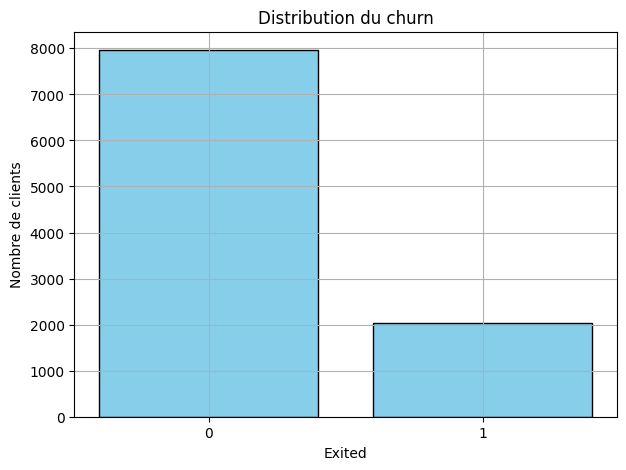

In [26]:
# 1. Combien de clients ont quitté la banque ?

exited_counts = df['Exited'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(exited_counts.index.astype(str), exited_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution du churn')
plt.xlabel('Exited')
plt.ylabel('Nombre de clients')
plt.grid()
plt.show()

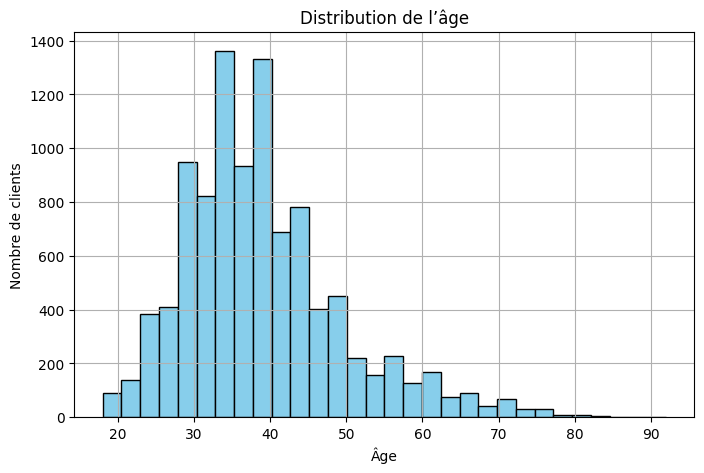

In [27]:
# 2. Quelle est la distribution de l’âge ?

plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution de l’âge')
plt.xlabel('Âge')
plt.ylabel('Nombre de clients')
plt.grid()
plt.show()

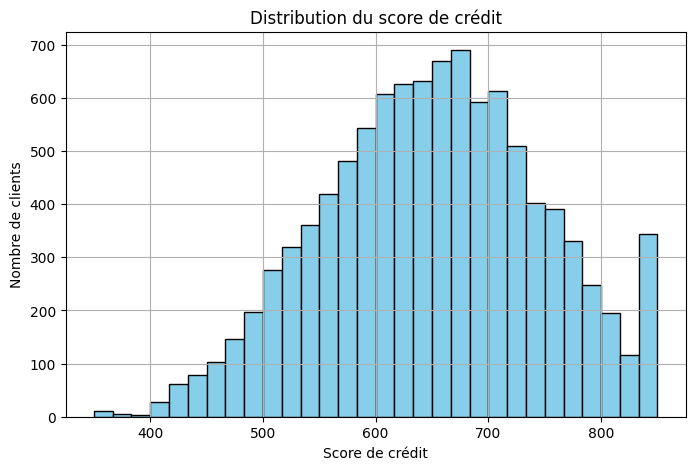

In [28]:
# 3. Quelle est la distribution du score de crédit ?

plt.figure(figsize=(8, 5))
plt.hist(df['CreditScore'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution du score de crédit')
plt.xlabel('Score de crédit')
plt.ylabel('Nombre de clients')
plt.grid()
plt.show()

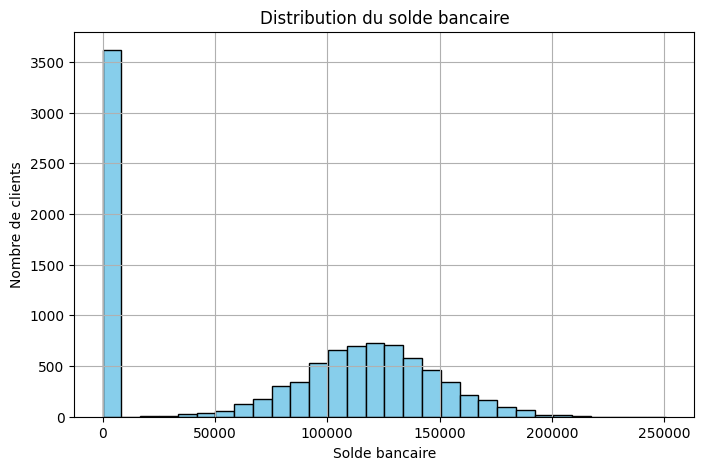

In [29]:
# 4. Quelle est la distribution du solde bancaire ?

plt.figure(figsize=(8, 5))
plt.hist(df['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution du solde bancaire')
plt.xlabel('Solde bancaire')
plt.ylabel('Nombre de clients')
plt.grid()
plt.show()

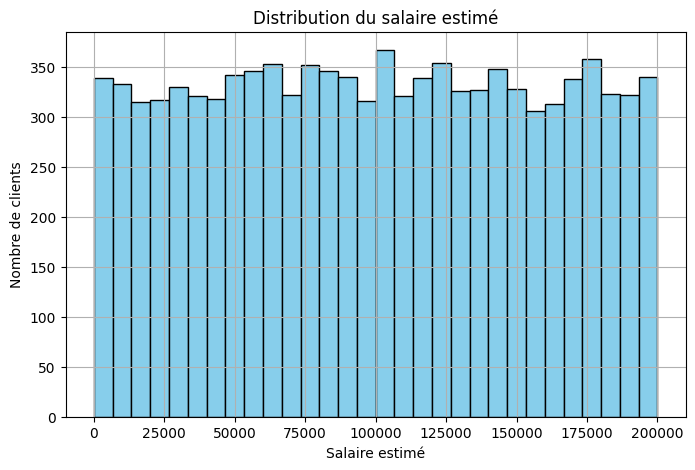

In [30]:
# 5. Quelle est la distribution du salaire estimé ?

plt.figure(figsize=(8, 5))
plt.hist(df['EstimatedSalary'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution du salaire estimé')
plt.xlabel('Salaire estimé')
plt.ylabel('Nombre de clients')
plt.grid()
plt.show()

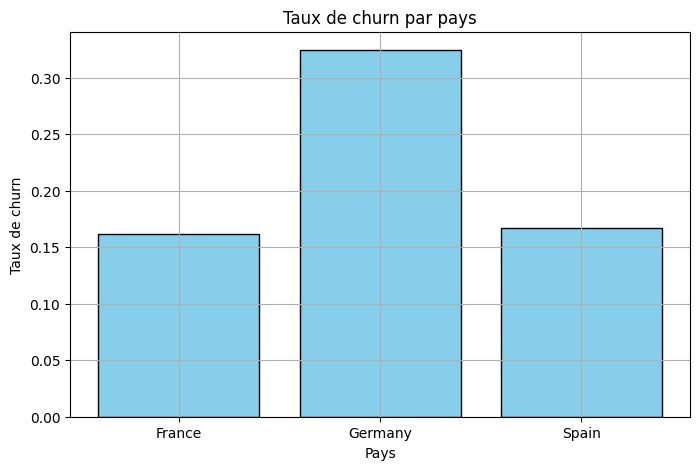

In [31]:
# 6. Quel est le taux de churn par pays ?

geography_churn = df.groupby('Geography')['Exited'].mean()

plt.figure(figsize=(8, 5))
plt.bar(geography_churn.index, geography_churn.values, color='skyblue', edgecolor='black')
plt.title('Taux de churn par pays')
plt.xlabel('Pays')
plt.ylabel('Taux de churn')
plt.grid()
plt.show()

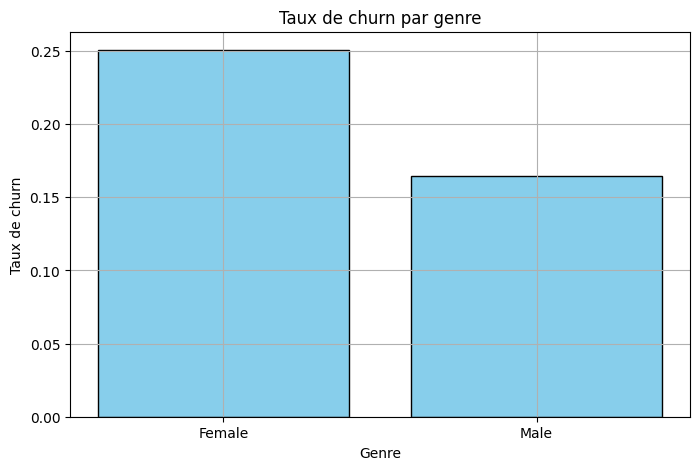

In [32]:
# 7. Quel est le taux de churn par genre ?

gender_churn = df.groupby('Gender')['Exited'].mean()

plt.figure(figsize=(8, 5))
plt.bar(gender_churn.index, gender_churn.values, color='skyblue', edgecolor='black')
plt.title('Taux de churn par genre')
plt.xlabel('Genre')
plt.ylabel('Taux de churn')
plt.grid()
plt.show()

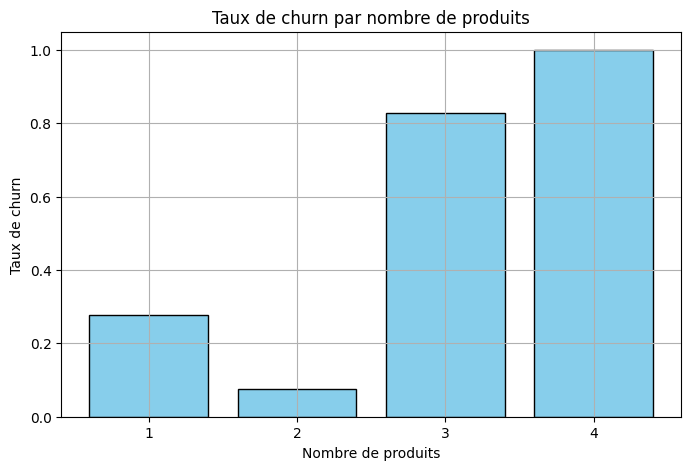

In [33]:
# 8. Quel est le taux de churn selon le nombre de produits ?

products_churn = df.groupby('NumOfProducts')['Exited'].mean()

plt.figure(figsize=(8, 5))
plt.bar(products_churn.index.astype(str), products_churn.values, color='skyblue', edgecolor='black')
plt.title('Taux de churn par nombre de produits')
plt.xlabel('Nombre de produits')
plt.ylabel('Taux de churn')
plt.grid()
plt.show()

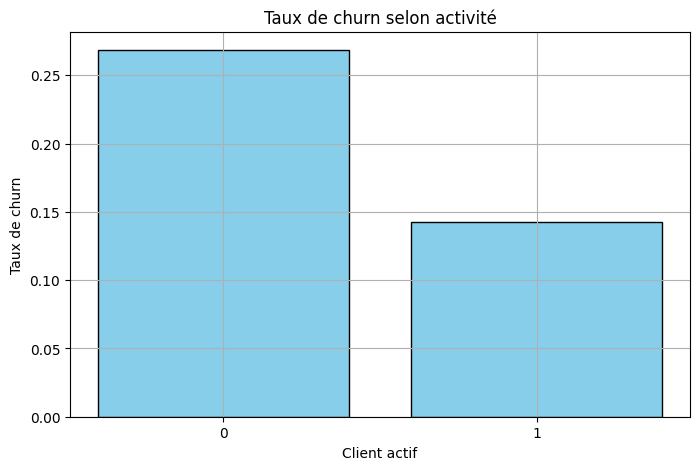

In [34]:
# 9. Quel est le taux de churn selon l’activité du client ?

active_churn = df.groupby('IsActiveMember')['Exited'].mean()

plt.figure(figsize=(8, 5))
plt.bar(active_churn.index.astype(str), active_churn.values, color='skyblue', edgecolor='black')
plt.title('Taux de churn selon activité')
plt.xlabel('Client actif')
plt.ylabel('Taux de churn')
plt.grid()
plt.show()

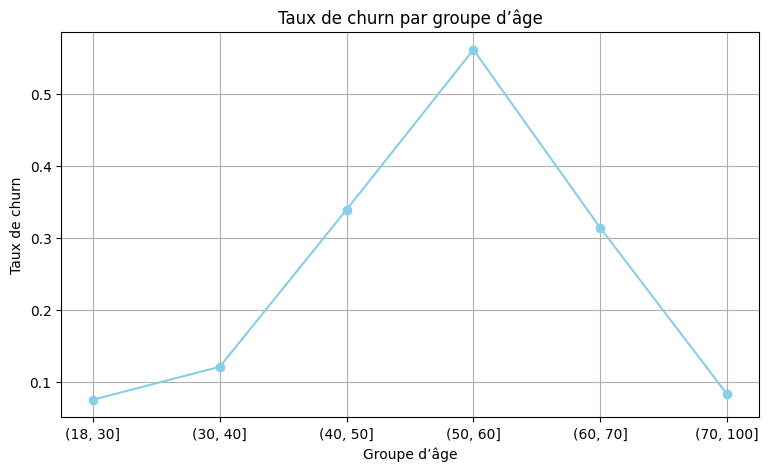

In [35]:
# 10. Comment le taux de churn évolue-t-il par groupe d’âge ?

df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 70, 100])
age_group_churn = df.groupby('AgeGroup')['Exited'].mean()

plt.figure(figsize=(9, 5))
plt.plot(age_group_churn.index.astype(str), age_group_churn.values, marker='o', color='skyblue')
plt.title('Taux de churn par groupe d’âge')
plt.xlabel('Groupe d’âge')
plt.ylabel('Taux de churn')
plt.grid()
plt.show()

# Section 5 — Feature Engineering

Cette section applique la préparation finale des variables.

On crée des variables supplémentaires pour aider les modèles à mieux comprendre les profils clients.

## Fonction de préparation des variables

Cette cellule crée une fonction `make_features` qui prépare les données :

- suppression des colonnes non utiles
- création de nouvelles variables
- encodage des variables catégorielles
- remplacement des valeurs infinies et manquantes

In [36]:
def make_features(data):
    X = data.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname']).copy()
    y = data['Exited'].astype(int)

    X['BalanceIsZero'] = (X['Balance'] == 0).astype(int)
    X['Age_NumOfProducts'] = X['Age'] * X['NumOfProducts']
    X['BalancePerProduct'] = X['Balance'] / X['NumOfProducts'].replace(0, 1)
    X['SalaryPerAge'] = X['EstimatedSalary'] / X['Age'].replace(0, np.nan)
    X['CreditScorePerAge'] = X['CreditScore'] / X['Age'].replace(0, np.nan)
    X['Active_Age'] = X['IsActiveMember'] * X['Age']
    X['Inactive_Age'] = (1 - X['IsActiveMember']) * X['Age']
    X['HighProducts'] = (X['NumOfProducts'] >= 3).astype(int)
    X['GermanyHighBalance'] = ((X['Geography'] == 'Germany') & (X['Balance'] > X['Balance'].median())).astype(int)

    X = pd.get_dummies(X, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    return X, y

## Application du feature engineering

Cette cellule applique la fonction sur le dataset complet.

In [37]:
df_for_model = df.drop(columns=['AgeGroup'], errors='ignore')

X, y = make_features(df_for_model)

feature_columns = list(X.columns)

print('Features shape:', X.shape)
X.head()

Features shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceIsZero,Age_NumOfProducts,BalancePerProduct,SalaryPerAge,CreditScorePerAge,Active_Age,Inactive_Age,HighProducts,GermanyHighBalance,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,42,0.000000,2413.068571,14.738095,42,0,0,0,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,41,83807.860000,2744.940976,14.829268,41,0,0,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,0,126,53220.266667,2712.656429,11.952381,0,42,1,0,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,1,78,0.000000,2405.811026,17.923077,0,39,0,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,43,125510.820000,1839.165116,19.767442,43,0,0,0,False,True,False


# Section 6 — SMOTE Balancing and Train/Test Split

Cette section applique SMOTE pour équilibrer les classes, puis divise les données en train set et test set.

Tous les modèles utiliseront les mêmes données préparées.

## Application de SMOTE

Cette cellule applique SMOTE afin d’équilibrer les classes.

In [38]:
smote = SMOTE(random_state=RANDOM_STATE)

X_res, y_res = smote.fit_resample(X, y)

print('Original class balance:')
display(y.value_counts())

print('After SMOTE class balance:')
display(y_res.value_counts())

Original class balance:


  File "c:\Users\marou\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\marou\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\marou\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\marou\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\marou\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1438, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Exited
0    7963
1    2037
Name: count, dtype: int64

After SMOTE class balance:


Exited
1    7963
0    7963
Name: count, dtype: int64

## Division train/test après SMOTE

Cette cellule divise les données équilibrées en données d’entraînement et données de test.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_res
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (12740, 20)
Test shape: (3186, 20)


## Feature Scaling

Cette cellule applique StandardScaler pour les modèles sensibles à l’échelle des variables.

Logistic Regression, KNN et SVC utilisent les données standardisées.  
Decision Tree et Random Forest utilisent les données non standardisées.

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.to_numpy())
X_test_scaled = scaler.transform(X_test.to_numpy())

# Section 7 — Training the 5 Algorithms

Cette section entraîne les 5 algorithmes avec les mêmes étapes de préparation.

Le modèle Random Forest remplace l’ancien Random Forest du notebook final et utilise les paramètres optimisés fournis.

## Définition des modèles

Cette cellule définit les 5 algorithmes utilisés dans le projet.

Le Random Forest est le nouveau modèle choisi comme modèle final.

In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=20,
        min_samples_split=40,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        max_depth=14,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE)
}

## Entraînement des modèles

Cette cellule entraîne chaque modèle sur les données préparées.

In [42]:
trained_models = {}

for model_name, model in models.items():
    if model_name in ['Decision Tree', 'Random Forest']:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train_scaled, y_train)

    trained_models[model_name] = model

trained_models

{'Logistic Regression': LogisticRegression(max_iter=1000),
 'KNN': KNeighborsClassifier(),
 'Decision Tree': DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, min_samples_split=40,
                        random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced_subsample', max_depth=14,
                        min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                        random_state=42),
 'SVC': SVC(probability=True, random_state=42)}

# Section 8 — Model Comparison

Cette section compare les modèles avec les métriques calculées sur les données d’entraînement.

Les métriques sont affichées de façon standard avec les noms :

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

## Évaluation des modèles

Cette cellule calcule les métriques principales pour les 5 modèles.

In [43]:
model_results = []
model_predictions = {}
model_probabilities = {}

for model_name, model in trained_models.items():
    if model_name in ['Decision Tree', 'Random Forest']:
        X_eval = X_train
    else:
        X_eval = X_train_scaled

    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    model_predictions[model_name] = y_pred
    model_probabilities[model_name] = y_proba

    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_train, y_pred),
        'Precision': precision_score(y_train, y_pred, zero_division=0),
        'Recall': recall_score(y_train, y_pred, zero_division=0),
        'F1 Score': f1_score(y_train, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_train, y_proba)
    })

results_df = pd.DataFrame(model_results)
results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Random Forest,0.957771,0.969414,0.945369,0.957241,0.994514
1,KNN,0.895918,0.899051,0.891994,0.895508,0.966501
4,SVC,0.877394,0.900400,0.848666,0.873768,0.950600
2,Decision Tree,0.860989,0.871306,0.847096,0.859030,0.936231
0,Logistic Regression,0.820958,0.818210,0.825275,0.821727,0.908059


# Section 9 — Comparison Graphs

Cette section affiche des graphiques de comparaison entre les 5 algorithmes.

## Comparaison Accuracy

Cette cellule compare l’Accuracy des 5 modèles.

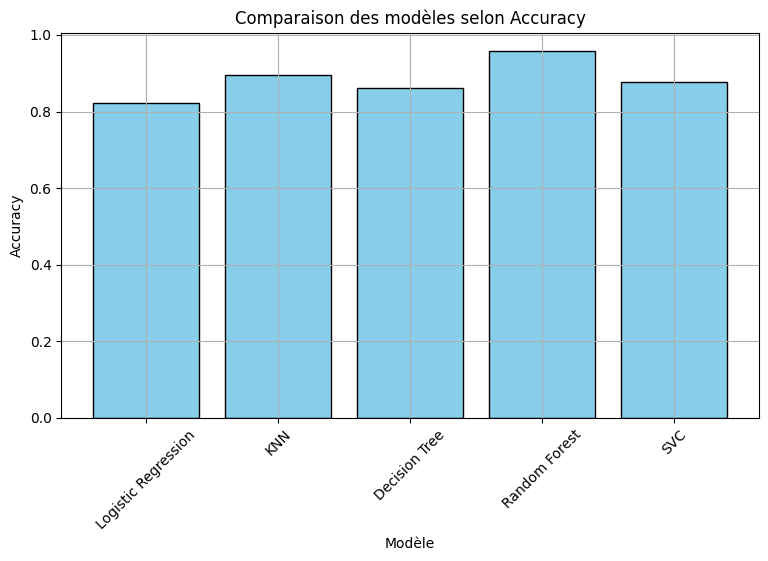

In [44]:
plt.figure(figsize=(9, 5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue', edgecolor='black')
plt.title('Comparaison des modèles selon Accuracy')
plt.xlabel('Modèle')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Comparaison F1-score

Cette cellule compare le F1-score des 5 modèles.

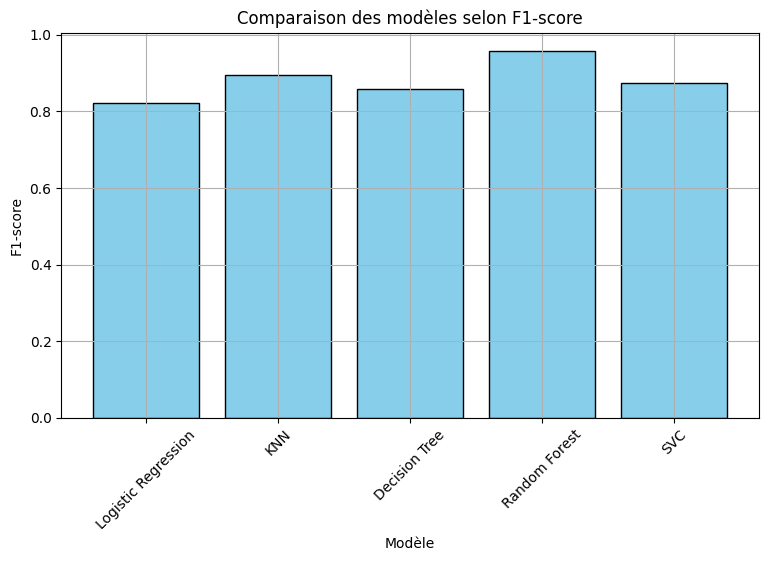

In [45]:
plt.figure(figsize=(9, 5))
plt.bar(results_df['Model'], results_df['F1 Score'], color='skyblue', edgecolor='black')
plt.title('Comparaison des modèles selon F1-score')
plt.xlabel('Modèle')
plt.ylabel('F1-score')
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Comparaison ROC-AUC

Cette cellule compare le ROC-AUC des 5 modèles.

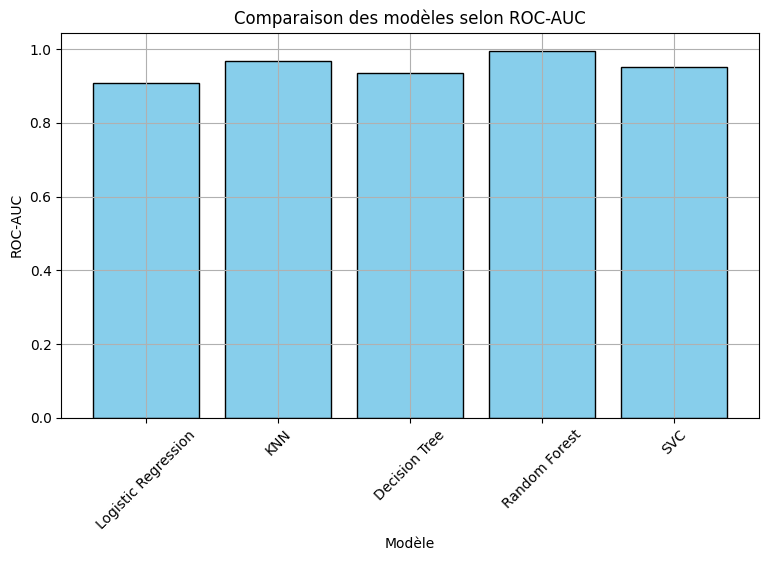

In [46]:
plt.figure(figsize=(9, 5))
plt.bar(results_df['Model'], results_df['ROC AUC'], color='skyblue', edgecolor='black')
plt.title('Comparaison des modèles selon ROC-AUC')
plt.xlabel('Modèle')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Section 10 — Confusion Matrices

Cette section affiche la matrice de confusion pour chaque modèle.

## Matrices de confusion des modèles

Cette cellule affiche une matrice de confusion pour chacun des 5 modèles.

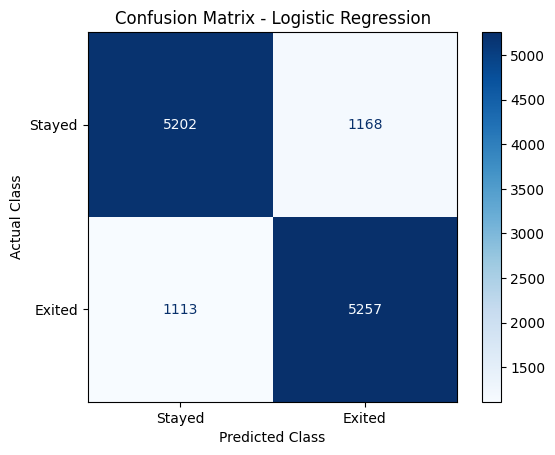

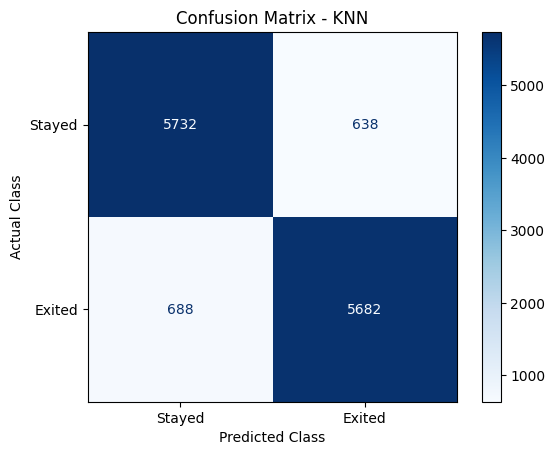

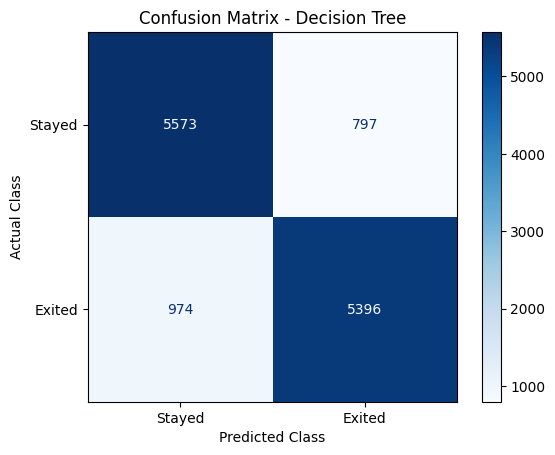

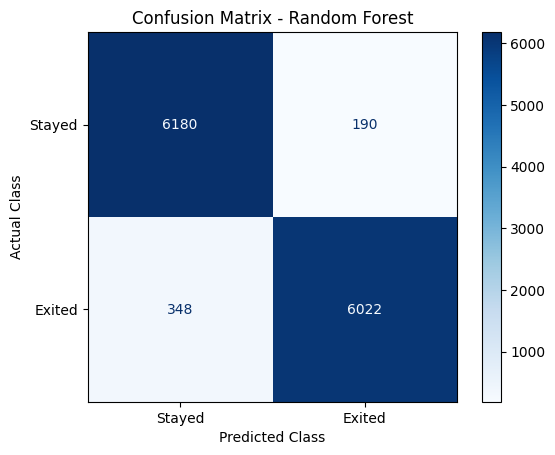

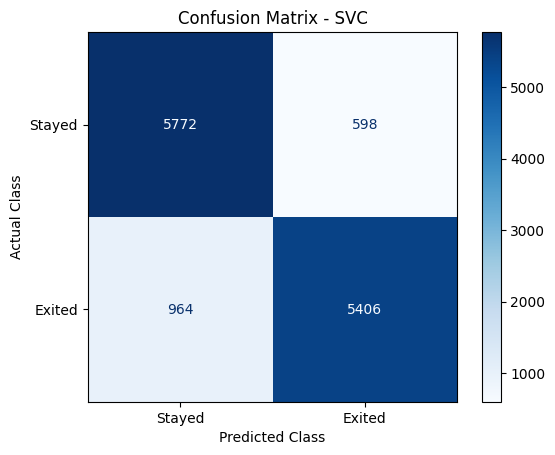

In [47]:
for model_name, y_pred in model_predictions.items():
    matrix = confusion_matrix(y_train, y_pred)

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=['Stayed', 'Exited']
    )

    cm_display.plot(cmap='Blues')

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.grid(False)
    plt.show()

# Section 11 — ROC-AUC Validation

Cette section affiche les courbes ROC-AUC de tous les modèles dans un seul graphique.

## Courbes ROC-AUC des 5 modèles

Cette cellule compare tous les modèles avec une courbe ROC-AUC.

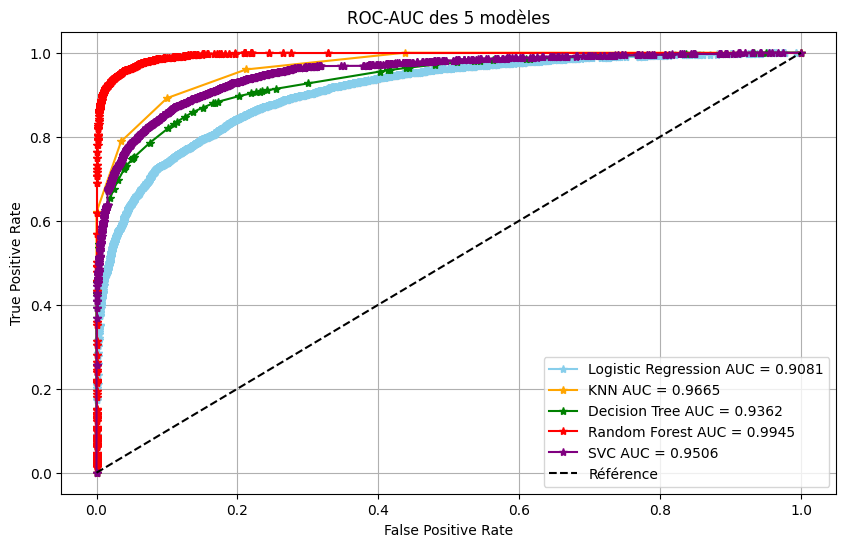

In [48]:
plt.figure(figsize=(10, 6))

colors = ['skyblue', 'orange', 'green', 'red', 'purple']

for index, (model_name, y_proba) in enumerate(model_probabilities.items()):
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train, y_proba)
    auc_score = roc_auc_score(y_train, y_proba)

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        marker='*',
        color=colors[index % len(colors)],
        label=f'{model_name} AUC = {auc_score:.4f}'
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Référence')
plt.title('ROC-AUC des 5 modèles')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()
plt.show()

# Section 12 — Final Model Selection

Cette section sélectionne le modèle final.

Même si les 5 modèles sont comparés dans le tableau, le modèle final choisi est **Random Forest** car c’est le modèle optimisé fourni pour remplacer l’ancien Random Forest.

## Sélection du modèle Random Forest

Cette cellule force la sélection du modèle final comme Random Forest.

In [49]:
best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]

best_model_name

'Random Forest'

## Résumé du modèle final

Cette cellule affiche les résultats du Random Forest.

In [50]:
final_model_summary = results_df[results_df['Model'] == best_model_name]

final_model_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Random Forest,0.957771,0.969414,0.945369,0.957241,0.994514


## Rapport de classification du modèle final

Cette cellule affiche le rapport de classification du Random Forest.

In [51]:
y_pred_best = model_predictions[best_model_name]

print(classification_report(
    y_train,
    y_pred_best,
    target_names=['Stayed', 'Exited']
))

              precision    recall  f1-score   support

      Stayed       0.95      0.97      0.96      6370
      Exited       0.97      0.95      0.96      6370

    accuracy                           0.96     12740
   macro avg       0.96      0.96      0.96     12740
weighted avg       0.96      0.96      0.96     12740



# Section 13 — Prediction on New Data

Cette section utilise le modèle final Random Forest pour prédire le churn d’un nouveau client.

## Préparation d’un nouveau client

Cette cellule crée un exemple de nouveau client.

In [52]:
new_customer = pd.DataFrame([{
    'CreditScore': 650,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0,
}])

new_customer

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,650,France,Male,40,3,60000.0,2,1,1,50000.0


## Préparation des colonnes du nouveau client

Cette cellule prépare le nouveau client avec la même fonction utilisée pendant l’entraînement.

In [53]:
dummy_target = pd.Series([0], name='Exited')

new_raw = pd.concat([new_customer, dummy_target], axis=1)
new_raw['RowNumber'] = 0
new_raw['CustomerId'] = 0
new_raw['Surname'] = 'Example'

new_raw = new_raw[df_for_model.columns]

new_X, _ = make_features(new_raw)
new_X = new_X.reindex(columns=feature_columns, fill_value=0)

new_X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceIsZero,Age_NumOfProducts,BalancePerProduct,SalaryPerAge,CreditScorePerAge,Active_Age,Inactive_Age,HighProducts,GermanyHighBalance,Geography_Germany,Geography_Spain,Gender_Male
0,650,40,3,60000.0,2,1,1,50000.0,0,80,30000.0,1250.0,16.25,40,0,0,0,0,0,0


## Prédiction finale

Cette cellule applique le modèle Random Forest au nouveau client.

In [54]:
prediction = best_model.predict(new_X)[0]
probability = best_model.predict_proba(new_X)[0, 1]

label = 'Client susceptible de quitter la banque' if prediction == 1 else 'Client susceptible de rester'

print('Prediction:', prediction)
print('Label:', label)
print('Churn probability:', round(probability, 4))

Prediction: 0
Label: Client susceptible de rester
Churn probability: 0.1523


# Section 14 — Saving and Loading the Final Model

Cette section sauvegarde le modèle final Random Forest et les fichiers nécessaires.

## Sauvegarde du modèle Random Forest

Cette cellule sauvegarde le modèle Random Forest, les colonnes, le scaler et l’objet SMOTE.

In [55]:
joblib.dump(best_model, MODELS_DIR / 'best_model_classifier.pkl')
joblib.dump(feature_columns, MODELS_DIR / 'feature_columns.pkl')
joblib.dump(smote, MODELS_DIR / 'smote.pkl')
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
joblib.dump(best_model_name, MODELS_DIR / 'best_model_name.pkl')

print(MODELS_DIR / 'best_model_classifier.pkl')
print(MODELS_DIR / 'feature_columns.pkl')
print(MODELS_DIR / 'smote.pkl')
print(MODELS_DIR / 'scaler.pkl')
print(MODELS_DIR / 'best_model_name.pkl')


c:\Users\marou\OneDrive\Desktop\AI\M102\data cleaning\marouan sellami\churn_modelling_project\models\best_model_classifier.pkl
c:\Users\marou\OneDrive\Desktop\AI\M102\data cleaning\marouan sellami\churn_modelling_project\models\feature_columns.pkl
c:\Users\marou\OneDrive\Desktop\AI\M102\data cleaning\marouan sellami\churn_modelling_project\models\smote.pkl
c:\Users\marou\OneDrive\Desktop\AI\M102\data cleaning\marouan sellami\churn_modelling_project\models\scaler.pkl
c:\Users\marou\OneDrive\Desktop\AI\M102\data cleaning\marouan sellami\churn_modelling_project\models\best_model_name.pkl


## Chargement du modèle sauvegardé

Cette cellule recharge les fichiers sauvegardés.

In [56]:
loaded_model = joblib.load(MODELS_DIR / 'best_model_classifier.pkl')
loaded_feature_columns = joblib.load(MODELS_DIR / 'feature_columns.pkl')
loaded_smote = joblib.load(MODELS_DIR / 'smote.pkl')
loaded_scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
loaded_model_name = joblib.load(MODELS_DIR / 'best_model_name.pkl')

print(type(loaded_model))
print(len(loaded_feature_columns))
print(type(loaded_smote))
print(type(loaded_scaler))
print(loaded_model_name)


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
20
<class 'imblearn.over_sampling._smote.base.SMOTE'>
<class 'sklearn.preprocessing._data.StandardScaler'>
Random Forest


# Conclusion

Ce notebook met à jour le projet final de churn bancaire en remplaçant l’ancien Random Forest par le nouveau modèle Random Forest optimisé.

Les 5 algorithmes sont entraînés avec la même méthode :

- feature engineering
- SMOTE
- train/test split
- entraînement
- évaluation
- comparaison graphique
- matrice de confusion
- ROC-AUC

Le modèle final choisi est **Random Forest**.

Les fichiers finaux sauvegardés sont :

- `best_model_classifier.pkl`
- `feature_columns.pkl`
- `smote.pkl`
- `scaler.pkl`
- `best_model_name.pkl`

Ce notebook garde le format standard du projet final.

## deployment of the model : 

- `GitHub repository : ` https://github.com/marouan-sell/churn_modelling_project

- `kaggle notebook : `   https://www.kaggle.com/code/nbslo82htkaa6/churn-modelling-project

- `siteweb : ` https://churnmodelling7.netlify.app/